#### 경로 설정
---

In [33]:
from pathlib import Path
import pandas as pd
import numpy as np

# 현재 노트북 위치: Donghaeng-LOTTO/analysis 라고 가정
PROJECT_ROOT = Path.cwd().parent

PROCESSED_DIR = PROJECT_ROOT / "kbo_pipeline" / "data" / "processed"

print(PROJECT_ROOT)
print(PROCESSED_DIR)
print(PROCESSED_DIR.exists())

d:\flatbass\Donghaeng-LOTTO
d:\flatbass\Donghaeng-LOTTO\kbo_pipeline\data\processed
True


### 데이터 불러오기
---

In [3]:
games = pd.read_csv(PROCESSED_DIR / "games.csv")
games_detail = pd.read_csv(PROCESSED_DIR / "games_detail.csv")

relay_events = pd.read_csv(PROCESSED_DIR / "relay_events.csv")
plate_appearances = pd.read_csv(PROCESSED_DIR / "plate_appearances.csv")

scoreboard = pd.read_csv(PROCESSED_DIR / "scoreboard_inning_scores.csv")
score_validation = pd.read_csv(PROCESSED_DIR / "score_validation.csv")
quality_report = pd.read_csv(PROCESSED_DIR / "dataset_quality_report.csv")

player_map = pd.read_csv(PROCESSED_DIR / "player_id_map.csv")
player_map_unmatched = pd.read_csv(PROCESSED_DIR / "player_id_map_unmatched.csv")
naver_players_seen = pd.read_csv(PROCESSED_DIR / "naver_players_seen.csv")

batter_box = pd.read_csv(PROCESSED_DIR / "batter_game_boxscores.csv")
batter_pre = pd.read_csv(PROCESSED_DIR / "batter_pre_game_stats.csv")

pitcher_box = pd.read_csv(PROCESSED_DIR / "pitcher_game_boxscores.csv")
pitcher_pre = pd.read_csv(PROCESSED_DIR / "pitcher_pre_game_stats.csv")

model_master = pd.read_csv(PROCESSED_DIR / "model_master_pa.csv")
model_master_eligible = pd.read_csv(PROCESSED_DIR / "model_master_pa_eligible.csv")

### 데이터 프레임 만들기
---

In [34]:
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / "kbo_pipeline" / "data" / "processed"

csv_files = sorted(PROCESSED_DIR.glob("*.csv"))

tables = {}

for path in csv_files:
    name = path.stem
    tables[name] = pd.read_csv(path, low_memory=False)
    print(f"{name:35s} rows={len(tables[name]):>8,} cols={len(tables[name].columns):>4}")

batter_game_boxscores               rows=   2,214 cols=  43
batter_pre_game_stats               rows=   2,214 cols=  22
dataset_quality_report              rows=      89 cols=  21
games                               rows=      89 cols=  16
games_detail                        rows=      89 cols=  17
model_master_pa                     rows=   6,941 cols= 207
model_master_pa_eligible            rows=   5,970 cols= 207
naver_players_seen                  rows=     502 cols=  18
pitcher_game_boxscores              rows=     701 cols=  26
pitcher_pre_game_stats              rows=     701 cols=  22
plate_appearances                   rows=   6,941 cols=  56
player_id_map                       rows=     270 cols=  17
player_id_map_unmatched             rows=      11 cols=  17
relay_events                        rows=  45,985 cols=  44
score_validation                    rows=      89 cols=   8
scoreboard_inning_scores            rows=      89 cols=  39


In [5]:
master_eligible = tables["model_master_pa_eligible"]
master_eligible

,game_id,relay_no,inning,home_or_away,start_seqno,result_seqno,end_seqno,batter_pcode,pitcher_pcode,batter_name,...,same_hand_matchup,batter_platoon_advantage,state_is_ok,score_is_valid,core_fields_notna,outs_before_valid,inning_valid,model_eligible_base,model_eligible_with_player_stats,model_exclusion_reasons
0,20080601HTOB0,1,1,0,1,6,6,74163,75230,이용규,...,False,True,True,True,True,True,True,True,True,NaN
1,20080601HTOB0,2,1,0,7,9,9,93607,75230,이종범,...,True,False,True,True,True,True,True,True,True,NaN
2,20080601HTOB0,3,1,0,10,15,15,96610,75230,장성호,...,False,True,True,True,True,True,True,True,True,NaN
3,20080601HTOB0,4,1,0,16,18,18,92304,75230,이재주,...,True,False,True,True,True,True,True,True,True,NaN
4,20080601HTOB0,5,1,0,19,26,26,70117,75230,최경환,...,False,True,True,True,True,True,True,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5965,20080629SSOB0,77,9,0,429,433,433,93410,77251,양준혁,...,False,True,True,True,True,True,True,True,True,NaN
5966,20080629SSOB0,78,9,0,434,441,441,74465,71260,박석민,...,True,False,True,True,True,True,True,True,True,NaN
5967,20080629SSOB0,80,9,1,443,450,450,70240,74454,정원석,...,True,False,True,True,True,True,True,True,True,NaN
5968,20080629SSOB0,82,9,1,452,459,459,72220,75421,유재웅,...,False,True,True,True,True,True,True,True,True,NaN


In [6]:
master_eligible.columns

Index(['game_id', 'relay_no', 'inning', 'home_or_away', 'start_seqno',
       'result_seqno', 'end_seqno', 'batter_pcode', 'pitcher_pcode',
       'batter_name',
       ...
       'same_hand_matchup', 'batter_platoon_advantage', 'state_is_ok',
       'score_is_valid', 'core_fields_notna', 'outs_before_valid',
       'inning_valid', 'model_eligible_base',
       'model_eligible_with_player_stats', 'model_exclusion_reasons'],
      dtype='str', length=207)

In [7]:
master_pa = tables["model_master_pa"]
master_pa

,game_id,relay_no,inning,home_or_away,start_seqno,result_seqno,end_seqno,batter_pcode,pitcher_pcode,batter_name,...,same_hand_matchup,batter_platoon_advantage,state_is_ok,score_is_valid,core_fields_notna,outs_before_valid,inning_valid,model_eligible_base,model_eligible_with_player_stats,model_exclusion_reasons
0,20080601HTOB0,1,1,0,1,6,6,74163,75230,이용규,...,False,True,True,True,True,True,True,True,True,NaN
1,20080601HTOB0,2,1,0,7,9,9,93607,75230,이종범,...,True,False,True,True,True,True,True,True,True,NaN
2,20080601HTOB0,3,1,0,10,15,15,96610,75230,장성호,...,False,True,True,True,True,True,True,True,True,NaN
3,20080601HTOB0,4,1,0,16,18,18,92304,75230,이재주,...,True,False,True,True,True,True,True,True,True,NaN
4,20080601HTOB0,5,1,0,19,26,26,70117,75230,최경환,...,False,True,True,True,True,True,True,True,True,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6936,20080629SSOB0,77,9,0,429,433,433,93410,77251,양준혁,...,False,True,True,True,True,True,True,True,True,NaN
6937,20080629SSOB0,78,9,0,434,441,441,74465,71260,박석민,...,True,False,True,True,True,True,True,True,True,NaN
6938,20080629SSOB0,80,9,1,443,450,450,70240,74454,정원석,...,True,False,True,True,True,True,True,True,True,NaN
6939,20080629SSOB0,82,9,1,452,459,459,72220,75421,유재웅,...,False,True,True,True,True,True,True,True,True,NaN


### EDA 시작용 기본 점검
---

In [35]:
def table_summary(df, name):
    return {
        "table": name,
        "rows": len(df),
        "cols": len(df.columns),
        "memory_mb": round(df.memory_usage(deep=True).sum() / 1024**2, 2),
        "duplicated_rows": df.duplicated().sum(),
    }

summary = pd.DataFrame([
    table_summary(df, name)
    for name, df in tables.items()
]).sort_values("rows", ascending=False)

summary

,table,rows,cols,memory_mb,duplicated_rows
13,relay_events,45985,44,41.95,0
5,model_master_pa,6941,207,26.67,0
10,plate_appearances,6941,56,8.20,0
6,model_master_pa_eligible,5970,207,22.56,0
0,batter_game_boxscores,2214,43,2.40,0
1,batter_pre_game_stats,2214,22,0.79,0
8,pitcher_game_boxscores,701,26,0.37,0
9,pitcher_pre_game_stats,701,22,0.26,0
7,naver_players_seen,502,18,0.32,0
11,player_id_map,270,17,0.19,0


### 컬럼 확인용
---

In [9]:
def show_columns(df, keyword=None):
    cols = list(df.columns)
    
    if keyword:
        cols = [c for c in cols if keyword.lower() in c.lower()]
    
    for c in cols:
        print(c)
        
show_columns(master_pa)

game_id
relay_no
inning
home_or_away
start_seqno
result_seqno
end_seqno
batter_pcode
pitcher_pcode
batter_name
batter_order
batter_pos_name_x
pitch_count
result_event_type
result_text
runner_before_result_text
runner_after_result_text
change_text
has_runner_movement_before_result
has_runner_movement_after_result
has_player_change
is_scoring_pa_result
pa_result_type
outs_before
base1_before
base2_before
base3_before
away_score_before
home_score_before
away_score_after
home_score_after
state_source
state_parse_status
parse_warning
base_state_before
pitcher_pcode_norm
pitcher_name
batter_pcode_norm
away_team_code
home_team_code
away_score
home_score
winner_team_code
is_top
batting_team_code
fielding_team_code
is_lotte_batting
is_lotte_fielding
lotte_score_before
opponent_score_before
score_diff_lotte_before
scoring_position_before
late_clutch
home_win
away_win
final_win_label_lotte
game_date
game_time
stadium
away_team_name
away_team_full_name
home_team_name
home_team_full_name
away_start

In [36]:
def missing_summary(df):
    result = (
        df.isna()
        .sum()
        .reset_index()
        .rename(columns={"index": "column", 0: "missing_count"})
    )
    result["missing_ratio"] = result["missing_count"] / len(df)
    return result.sort_values("missing_ratio", ascending=False)

missing_summary(master_pa).head(30)

,column,missing_count,missing_ratio
144,pitcher_pos_name,6745,0.971762
15,runner_before_result_text,6674,0.961533
17,change_text,6176,0.889785
33,parse_warning,6003,0.864861
206,model_exclusion_reasons,5970,0.860107
48,lotte_score_before,5257,0.757384
49,opponent_score_before,5257,0.757384
50,score_diff_lotte_before,5257,0.757384
93,lotte_win_label,5257,0.757384
55,final_win_label_lotte,5257,0.757384


### 모델 마스터 테이블(model_master_pa)
---

In [37]:
master = tables["model_master_pa"]
eligible = tables["model_master_pa_eligible"]

master.shape, eligible.shape

((6941, 207), (5970, 207))

##### 학습 가능 행 비율(데이터 누수 방지를 위해)
---

In [38]:
master["model_eligible_base"].value_counts(dropna=False)

model_eligible_base
True     5972
False     969
Name: count, dtype: int64

In [39]:
master["model_eligible_with_player_stats"].value_counts(dropna=False)

model_eligible_with_player_stats
True     5970
False     971
Name: count, dtype: int64

- 제외사유
---

In [40]:
master["model_exclusion_reasons"].value_counts(dropna=False).head(20)

model_exclusion_reasons
NaN                                 5970
state_not_ok                         815
state_not_ok;invalid_outs_before     123
invalid_outs_before                   31
missing_pitcher_pre_stats              2
Name: count, dtype: int64

#### 승패 라벨 분포 확인
---

In [15]:
eligible["batting_team_win_label"].value_counts(dropna=False)

batting_team_win_label
1.0    3036
0.0    2934
Name: count, dtype: int64

In [16]:
eligible["home_win_label"].value_counts(dropna=False)

home_win_label
1.0    3460
0.0    2510
Name: count, dtype: int64

In [17]:
eligible["lotte_win_label"].value_counts(dropna=False)

lotte_win_label
NaN    4516
0.0     729
1.0     725
Name: count, dtype: int64

- 비율로 보기

In [18]:
eligible["batting_team_win_label"].value_counts(normalize=True, dropna=False)

batting_team_win_label
1.0    0.508543
0.0    0.491457
Name: proportion, dtype: float64

#### 이닝별 공격팀 승률 보기
---

In [19]:
inning_win = (
    eligible
    .groupby("inning")["batting_team_win_label"]
    .mean()
    .reset_index()
)

inning_win

,inning,batting_team_win_label
0,1,0.525148
1,2,0.515337
2,3,0.515837
3,4,0.513473
4,5,0.525849
5,6,0.539589
6,7,0.515576
7,8,0.518195
8,9,0.382294
9,10,0.405405


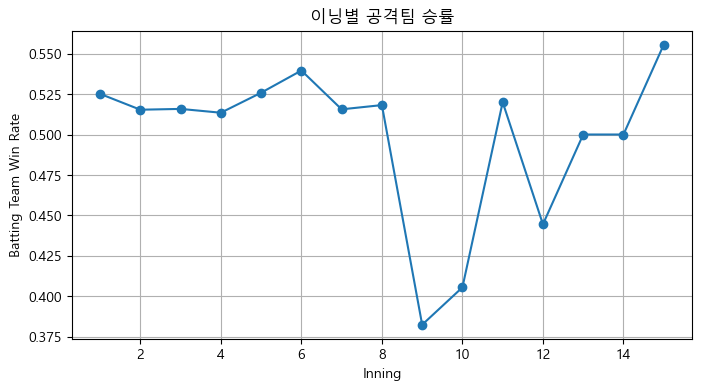

In [23]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib as mpl

# Windows 기본 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"

# 마이너스 깨짐 방지
plt.rcParams["axes.unicode_minus"] = False

# 기본 그래프 크기
plt.rcParams["figure.figsize"] = (10, 5)

# 해상도
plt.rcParams["figure.dpi"] = 100

plt.figure(figsize=(8, 4))
plt.plot(inning_win["inning"], inning_win["batting_team_win_label"], marker="o")
plt.xlabel("Inning")
plt.ylabel("Batting Team Win Rate")
plt.title("이닝별 공격팀 승률")
plt.grid(True)
plt.show()

#### 점수차별 승률 보기
---

In [25]:
score_diff_win = (
    eligible
    .groupby("batting_score_diff_before")["batting_team_win_label"]
    .agg(["count", "mean"])
    .reset_index()
    .sort_values("batting_score_diff_before")
)

score_diff_win

# 표본이 너무 적은 점수차는 제외
score_diff_win_filtered = score_diff_win[score_diff_win["count"] >= 20]
score_diff_win_filtered

,batting_score_diff_before,count,mean
6,-11,35,0.000000
7,-10,49,0.000000
8,-9,32,0.000000
9,-8,66,0.000000
10,-7,85,0.000000
11,-6,117,0.000000
12,-5,242,0.000000
13,-4,267,0.000000
14,-3,272,0.084559
15,-2,356,0.224719


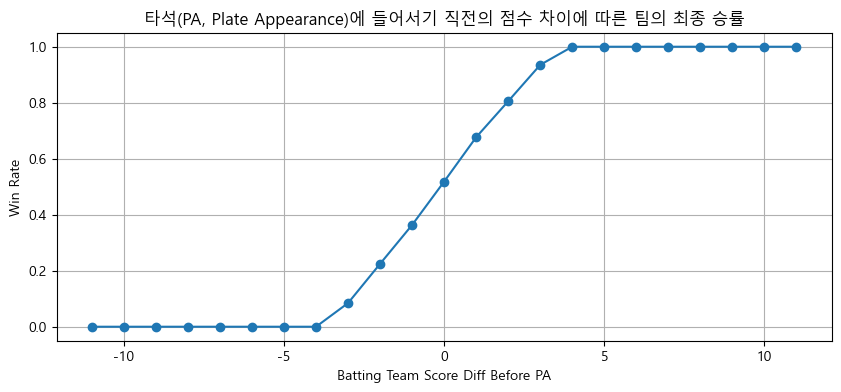

In [27]:
plt.figure(figsize=(10, 4))
plt.plot(
    score_diff_win_filtered["batting_score_diff_before"],
    score_diff_win_filtered["mean"],
    marker="o"
)
plt.xlabel("Batting Team Score Diff Before PA")
plt.ylabel("Win Rate")
plt.title("타석(PA, Plate Appearance)에 들어서기 직전의 점수 차이에 따른 팀의 최종 승률")
plt.grid(True)
plt.show()

#### 아웃/주자 상태별 승률
---

In [29]:
base_out_win = (
    eligible
    .groupby(["outs_before", "base_state_before"])["batting_team_win_label"]
    .agg(["count", "mean"])
    .reset_index()
    .sort_values(["outs_before", "base_state_before"])
)

base_out_win

# 표본 20개 이상만
base_out_win[base_out_win["count"] >= 20]

,outs_before,base_state_before,count,mean
0,0,0,1631,0.494788
1,0,1,37,0.837838
2,0,10,105,0.561905
3,0,11,20,0.550000
4,0,100,345,0.507246
8,1,0,1182,0.483926
9,1,1,111,0.666667
10,1,10,252,0.535714
11,1,11,27,0.629630
12,1,100,357,0.495798


#### 롯데 경기만 보기
---

In [30]:
lotte = eligible[
    (eligible["home_team_code"] == "LT") |
    (eligible["away_team_code"] == "LT")
].copy()

lotte.shape

(1454, 207)

#### 롯데 공격 상황만
---

In [31]:
lotte_batting = lotte[lotte["batting_team_code"] == "LT"].copy()

lotte_batting.shape

(716, 207)

#### 롯데 공격 시 점수차별 최종 승률
---

In [32]:
lotte_score_diff = (
    lotte_batting
    .groupby("batting_score_diff_before")["lotte_win_label"]
    .agg(["count", "mean"])
    .reset_index()
    .sort_values("batting_score_diff_before")
)

lotte_score_diff

,batting_score_diff_before,count,mean
0,-6,6,0.000000
1,-5,20,0.000000
2,-4,49,0.000000
3,-3,34,0.029412
4,-2,40,0.350000
5,-1,146,0.356164
6,0,201,0.537313
7,1,58,0.586207
8,2,44,0.704545
9,3,17,1.000000
